## Timescales for thermalization

Let $\ket{\psi(0)} = \ket{k_0}$ and let $\ket{k}$ to be eigenstates of the hamiltonian.

Then the projection of $\ket{\psi(t)}$ onto $\ket{k}$ is $C^{k_0}_k(t)$

We define evolution of the participation entropy as follows 

$$\langle \chi_{\mathrm{ent}}(t) \rangle = \bigg \langle -\ln\bigg (\sum_{k=1}^D |C^{k_0}_k(t)|^4 \bigg) \bigg \rangle$$

The $\langle \cdot \rangle$ denotes average over initial states.

Let the initial state be a random state with $S_z =0$.

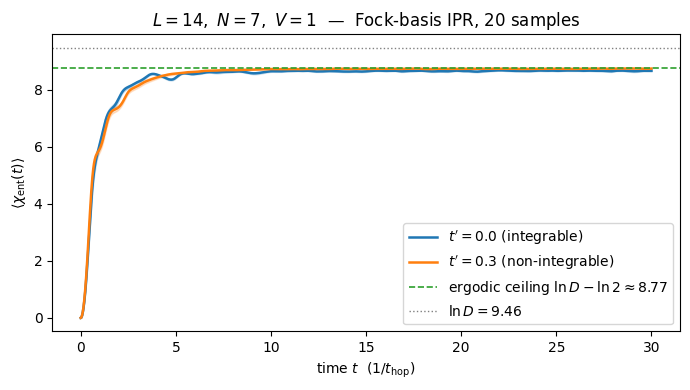

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, re
from math import comb

def load_csv(path):
    df = pd.read_csv(path, comment="#")
    ln_D, ceiling, n_samples = None, None, None
    with open(path) as f:
        for line in f:
            if "ln(D)" in line and "ceiling" in line:
                ln_D    = float(line.split("ln(D) =")[1].split()[0])
                ceiling = float(line.split("≈")[1].split()[0])
            if "averaged over" in line:
                m = re.search(r'averaged over \d+/(\d+)', line)   # new format: sample/n_samples
                if not m:
                    m = re.search(r'averaged over (\d+) random', line)  # old format
                if m:
                    n_samples = int(m.group(1))
    return df, ln_D, ceiling, n_samples

df_int,  ln_D, ceiling, n_samples = load_csv("results/participation_entropy_L16_tp0.000_Vp0.000.csv")
df_pert, *_                       = load_csv("results/participation_entropy_L16_tp0.300_Vp0.300.csv")

fig, ax = plt.subplots(figsize=(7, 4))

for df, tp, color in [(df_int, 0.0, "C0"), (df_pert, 0.3, "C1")]:
    sem = df["chi_ent_std"] / np.sqrt(n_samples)
    label = r"$t'=%.1f$ (%s)" % (tp, "integrable" if tp == 0.0 else "non-integrable")
    ax.fill_between(df["time"], df["chi_ent_mean"] - sem,
                                df["chi_ent_mean"] + sem,
                    alpha=0.2, color=color)
    ax.plot(df["time"], df["chi_ent_mean"], color=color, lw=1.8, label=label)

ax.axhline(ceiling, ls="--", color="C2", lw=1.2,
           label=r"ergodic ceiling $\ln D - \ln 2 \approx %.2f$" % ceiling)
ax.axhline(ln_D, ls=":", color="gray", lw=1.0,
           label=r"$\ln D = %.2f$" % ln_D)

ax.set_xlabel(r"time $t$  ($1/t_\mathrm{hop}$)")
ax.set_ylabel(r"$\langle\chi_\mathrm{ent}(t)\rangle$")
ax.set_title(rf"$L=14,\ N=7,\ V=1$  —  Fock-basis IPR, {n_samples} samples")
ax.legend()
plt.tight_layout()
plt.show()

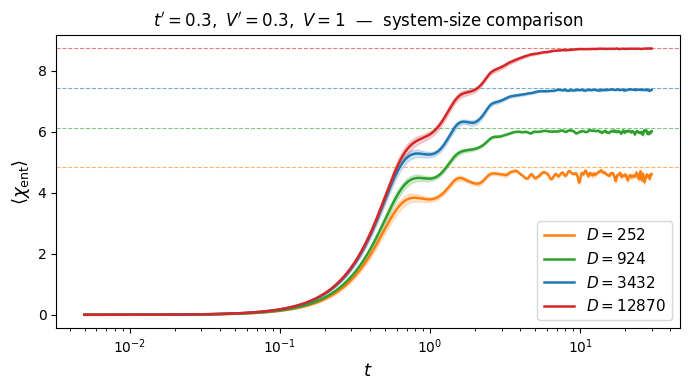

In [5]:
sizes = [10, 12, 14, 16]
colors = ["C1", "C2", "C0", "C3"]

fig, ax = plt.subplots(figsize=(7, 4))

for L, color in zip(sizes, colors):
    path = f"results/participation_entropy_L{L}_tp0.300_Vp0.300.csv"
    df, ln_D, ceiling, n_samples = load_csv(path)
    D = comb(L, L // 2)
    sem  = df["chi_ent_std"] / np.sqrt(n_samples)
    mask = df["time"] > 0
    ax.fill_between(df["time"][mask], (df["chi_ent_mean"] - sem)[mask],
                                      (df["chi_ent_mean"] + sem)[mask],
                    alpha=0.2, color=color)
    ax.plot(df["time"][mask], df["chi_ent_mean"][mask], color=color, lw=1.8,
            label=rf"$D={D}$")
    ax.axhline(ceiling, ls="--", color=color, lw=0.8, alpha=0.6)

ax.set_xscale("log")
ax.set_xlabel(r"$t$", fontsize=13)
ax.set_ylabel(r"$\langle \chi_\mathrm{ent} \rangle$", fontsize=13)
ax.set_title(r"$t'=0.3,\ V'=0.3,\ V=1$  —  system-size comparison")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

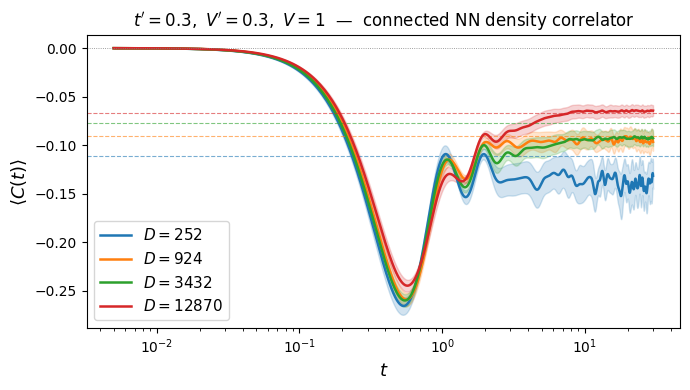

In [6]:
sizes = [10, 12, 14, 16]
colors = ["C0", "C1", "C2", "C3"]

fig, ax = plt.subplots(figsize=(7, 4))

for L, color in zip(sizes, colors):
    path = f"results/participation_entropy_L{L}_tp0.300_Vp0.300.csv"
    df, _, _, n_samples = load_csv(path)
    D = comb(L, L // 2)
    plateau = -1.0 / (L - 1)
    sem  = df["C_std"] / np.sqrt(n_samples)
    mask = df["time"] > 0
    ax.fill_between(df["time"][mask], (df["C_mean"] - sem)[mask],
                                      (df["C_mean"] + sem)[mask],
                    alpha=0.2, color=color)
    ax.plot(df["time"][mask], df["C_mean"][mask], color=color, lw=1.8,
            label=rf"$D={D}$")
    ax.axhline(plateau, ls="--", color=color, lw=0.8, alpha=0.6)

ax.axhline(0, color="gray", lw=0.6, ls=":")
ax.set_xscale("log")
ax.set_xlabel(r"$t$", fontsize=13)
ax.set_ylabel(r"$\langle C(t) \rangle$", fontsize=13)
ax.set_title(r"$t'=0.3,\ V'=0.3,\ V=1$  —  connected NN density correlator")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Thermalization time scaling

In [7]:
# ── Step 1: Load and inspect all participation entropy files ─────────────────
files = sorted(glob.glob("results/participation_entropy_*.csv"))
records = []
print(f"Found {len(files)} files:\n")
print(f"  {'L':>4}  {'tp':>6}  {'Vp':>6}  {'D':>8}  {'t_range':>16}  {'n_t':>6}")
for path in files:
    m = re.search(r"L(\d+)_tp([0-9.]+)_Vp([0-9.]+)\.csv", path)
    L, tp, Vp = int(m.group(1)), float(m.group(2)), float(m.group(3))
    D = comb(L, L // 2)
    df, ln_D, ceiling, n_samples = load_csv(path)
    t0, t1, nt = df["time"].min(), df["time"].max(), len(df)
    records.append(dict(L=L, tp=tp, Vp=Vp, D=D, df=df, path=path, n_samples=n_samples))
    print(f"  {L:4d}  {tp:6.3f}  {Vp:6.3f}  {D:8d}  [{t0:.3f}, {t1:.3f}]  {nt:6d}")

Found 8 files:

     L      tp      Vp         D           t_range     n_t
    10   0.000   0.000       252  [0.000, 30.000]    6001
    10   0.300   0.300       252  [0.000, 30.000]    6001
    12   0.000   0.000       924  [0.000, 30.000]    6001
    12   0.300   0.300       924  [0.000, 30.000]    6001
    14   0.000   0.000      3432  [0.000, 30.000]    6001
    14   0.300   0.300      3432  [0.000, 30.000]    6001
    16   0.000   0.000     12870  [0.000, 30.000]    6001
    16   0.300   0.300     12870  [0.000, 30.000]    6001


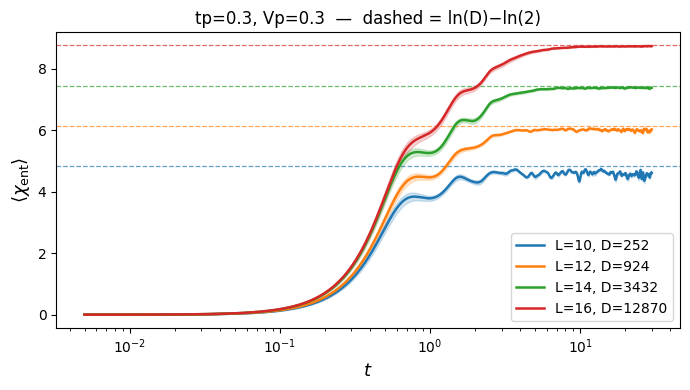


   L       D    ceiling    plateau       gap  saturated?
  10     252     4.8363     4.5459    0.2903  no  (gap=0.290)
  12     924     6.1356     5.9909    0.1447  yes
  14    3432     7.4478     7.3715    0.0762  yes
  16   12870     8.7695     8.7346    0.0349  yes


In [8]:
assert 'records' in globals(), "Run the file-loading cell first"

# ── Step 2: Raw curves for tp=0.3, Vp=0.3 ────────────────────────────────────
tp_sel, Vp_sel = 0.3, 0.3
sel = sorted([r for r in records if abs(r["tp"]-tp_sel)<1e-9 and abs(r["Vp"]-Vp_sel)<1e-9],
             key=lambda r: r["L"])
colors = [f"C{i}" for i in range(len(sel))]

fig, ax = plt.subplots(figsize=(7, 4))
for r, c in zip(sel, colors):
    df, L, D = r["df"], r["L"], r["D"]
    ceiling = np.log(D) - np.log(2)
    sem  = df["chi_ent_std"] / np.sqrt(r["n_samples"])
    mask = df["time"] > 0
    ax.fill_between(df["time"][mask], (df["chi_ent_mean"]-sem)[mask],
                    (df["chi_ent_mean"]+sem)[mask], alpha=0.2, color=c)
    ax.plot(df["time"][mask], df["chi_ent_mean"][mask], color=c, lw=1.8,
            label=f"L={L}, D={D}")
    ax.axhline(ceiling, ls="--", color=c, lw=0.9, alpha=0.7)

ax.set_xscale("log")
ax.set_xlabel(r"$t$", fontsize=13)
ax.set_ylabel(r"$\langle\chi_\mathrm{ent}\rangle$", fontsize=13)
ax.set_title(f"tp={tp_sel}, Vp={Vp_sel}  —  dashed = ln(D)−ln(2)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n{'L':>4}  {'D':>6}  {'ceiling':>9}  {'plateau':>9}  {'gap':>8}  saturated?")
for r in sel:
    df, L, D = r["df"], r["L"], r["D"]
    ceiling = np.log(D) - np.log(2)
    plateau = df["chi_ent_mean"].iloc[int(0.9*len(df)):].mean()
    gap = ceiling - plateau
    sat = "yes" if abs(gap) < 0.05 * ceiling else f"no  (gap={gap:.3f})"
    print(f"  {L:2d}  {D:6d}  {ceiling:9.4f}  {plateau:9.4f}  {gap:8.4f}  {sat}")

In [9]:
assert 'sel' in globals(), "Run the raw-curves cell first"

# ── Step 3: Extract t_therm for f ∈ {0.60, ..., 0.95} ───────────────────────
# t_therm is defined as the first time χ_ent reaches f * plateau (late-time mean).
# Uses plateau rather than the ergodic ceiling: robust when the run hasn't fully
# saturated, but gives a shorter apparent t_therm if plateau < ceiling.
thresholds = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
results = {f: [] for f in thresholds}

for f in thresholds:
    print(f"f = {f:.2f}")
    print(f"  {'L':>4}  {'D':>6}  {'plateau':>9}  {'ln(D)-ln2':>10}  {'t_therm':>9}")
    for r in sel:
        df, L, D = r["df"], r["L"], r["D"]
        ceiling  = np.log(D) - np.log(2)
        n_tail   = max(1, int(0.1 * len(df)))
        plateau  = df["chi_ent_mean"].iloc[-n_tail:].mean()
        reached  = df["chi_ent_mean"] >= f * plateau
        t_therm  = df["time"][reached].iloc[0] if reached.any() else float("nan")
        results[f].append(dict(L=L, D=D, plateau=plateau, ceiling=ceiling, t_therm=t_therm))
        print(f"  {L:4d}  {D:6d}  {plateau:9.4f}  {ceiling:10.4f}  {t_therm:9.4f}")
    print()

f = 0.60
     L       D    plateau   ln(D)-ln2    t_therm
    10     252     4.5461      4.8363     0.4950
    12     924     5.9908      6.1356     0.5600
    14    3432     7.3715      7.4478     0.5700
    16   12870     8.7346      8.7695     0.6650

f = 0.65
     L       D    plateau   ln(D)-ln2    t_therm
    10     252     4.5461      4.8363     0.5200
    12     924     5.9908      6.1356     0.6050
    14    3432     7.3715      7.4478     0.6200
    16   12870     8.7346      8.7695     0.8000

f = 0.70
     L       D    plateau   ln(D)-ln2    t_therm
    10     252     4.5461      4.8363     0.5550
    12     924     5.9908      6.1356     0.6600
    14    3432     7.3715      7.4478     0.7100
    16   12870     8.7346      8.7695     1.1150

f = 0.75
     L       D    plateau   ln(D)-ln2    t_therm
    10     252     4.5461      4.8363     0.5950
    12     924     5.9908      6.1356     1.0700
    14    3432     7.3715      7.4478     1.2200
    16   12870     8.7346     

**Note:** The power law fit below uses only 4 system sizes (L = 10, 12, 14, 16), leaving 2 degrees of freedom. The wide range of γ across thresholds f reflects both statistical uncertainty and the possibility that these system sizes are not yet in the asymptotic scaling regime. Results should be treated as indicative, not conclusive.

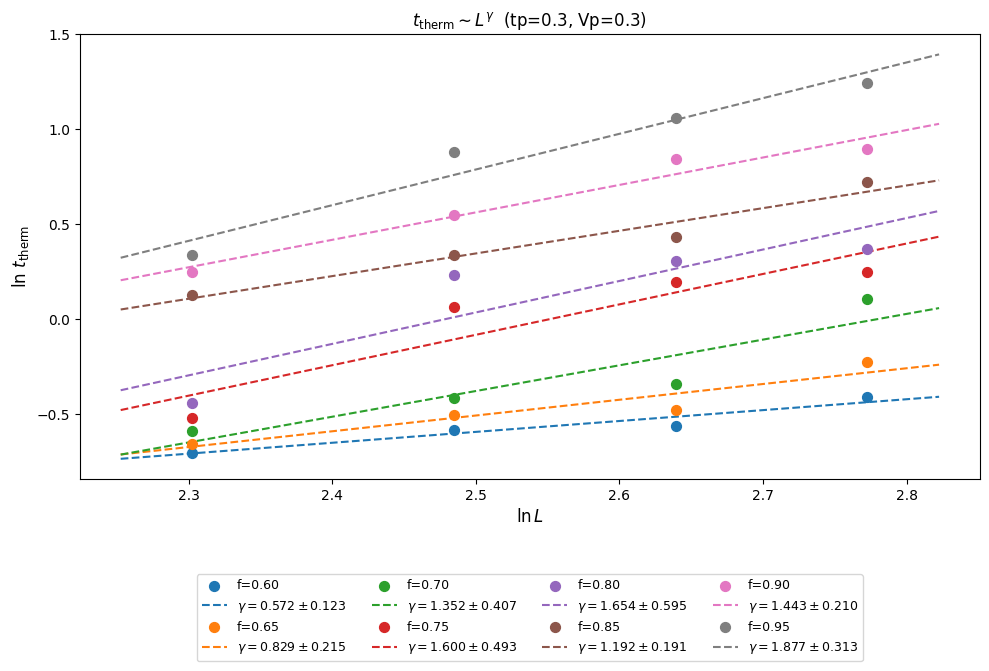

In [10]:
assert 'results' in globals(), "Run the t_therm extraction cell first"

# ── Step 4: Fit t_therm ~ L^γ ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fit_results = {}

for f, c in zip(thresholds, ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7"]):
    rows   = [r for r in results[f] if not np.isnan(r["t_therm"])]
    Ls     = np.array([r["L"] for r in rows])
    ts     = np.array([r["t_therm"] for r in rows])
    log_L  = np.log(Ls)
    log_t  = np.log(ts)

    A      = np.vstack([log_L, np.ones(len(log_L))]).T
    γ, b   = np.linalg.lstsq(A, log_t, rcond=None)[0]
    resid  = log_t - (γ * log_L + b)
    n, p   = len(log_L), 2
    se     = np.sqrt(resid @ resid / (n - p)) if n > p else float("nan")
    γ_err  = se * np.sqrt(np.linalg.inv(A.T @ A)[0, 0])
    fit_results[f] = (γ, γ_err)

    ax.scatter(log_L, log_t, color=c, zorder=3, s=50, label=f"f={f:.2f}")
    L_plot = np.linspace(log_L.min() - 0.05, log_L.max() + 0.05, 60)
    ax.plot(L_plot, γ * L_plot + b, color=c, lw=1.5, ls="--",
            label=fr"$\gamma={γ:.3f}\pm{γ_err:.3f}$")

ax.set_xlabel(r"$\ln L$", fontsize=12)
ax.set_ylabel(r"$\ln\, t_\mathrm{therm}$", fontsize=12)
ax.set_title(r"$t_\mathrm{therm} \sim L^\gamma$  (tp=0.3, Vp=0.3)")
ax.legend(fontsize=9,ncol=4,loc="upper center",bbox_to_anchor=(0.5,-0.2))
plt.tight_layout()
plt.show()

In [11]:
assert 'fit_results' in globals(), "Run the fitting cell first"

# ── Step 5: Summary ───────────────────────────────────────────────────────────
print("=" * 48)
print("  γ ± uncertainty  (t_therm ~ L^γ,  tp=0.3 Vp=0.3)")
print("=" * 48)
γ_vals = []
for f in thresholds:
    γ, γ_err = fit_results[f]
    γ_vals.append(γ)
    print(f"  f = {f:.2f}:  γ = {γ:.3f} ± {γ_err:.3f}")

γ_range = max(γ_vals) - min(γ_vals)
stable  = γ_range < 0.1
print(f"\n  Range of γ across thresholds: {γ_range:.3f}")
print(f"  Stable (range < 0.1): {'YES' if stable else 'NO'}")

  γ ± uncertainty  (t_therm ~ L^γ,  tp=0.3 Vp=0.3)
  f = 0.60:  γ = 0.572 ± 0.123
  f = 0.65:  γ = 0.829 ± 0.215
  f = 0.70:  γ = 1.352 ± 0.407
  f = 0.75:  γ = 1.600 ± 0.493
  f = 0.80:  γ = 1.654 ± 0.595
  f = 0.85:  γ = 1.192 ± 0.191
  f = 0.90:  γ = 1.443 ± 0.210
  f = 0.95:  γ = 1.877 ± 0.313

  Range of γ across thresholds: 1.304
  Stable (range < 0.1): NO


In [4]:
16**1.3

36.75834735990512